In [1]:
import numpy as np              # load numerical module
import matplotlib.pyplot as plt # load plotting module
import astropy.io.fits as fits  # get FITS 
import pandas as pd             # get pandas 
import os                       #import os module
from mpl_toolkits.mplot3d import Axes3D
import gaussian as g
import radprof as R
import disk as d
import matplotlib.patches as pat
from astropy import modeling
from photutils.centroids import centroid_com, centroid_2dg

### Recap of SNR concepts we have seen so far:

### Figure of merit for all measurements: Signal-to-noise ratio (S/N or SNR or SN)  <br><br> $$ \mathrm{SNR} = \frac{\mbox{value of corrected measurement}}{\mbox{random error in that value}} = \frac{\bar x}{\sigma}$$

### when reading our CCD: $\mathrm{SNR} = \frac{ N_\mathrm{target} }{ \sigma_\mathrm{tot} } = \frac{ N_\mathrm{target} }{ \sqrt{ \sigma_\mathrm{target}^2  + \sigma_{dark,sky,read}^2 } } = \frac{ N_\mathrm{target} }{ \sqrt{ \sigma_\mathrm{target}^2  + n_\mathrm{pixels, target} ( \sigma_\mathrm{dark}^2+ \sigma_\mathrm{sky}^2 + \sigma_\mathrm{read}^2 )} } $ <br> or putting it all in photon counts: 

$$ \mathrm{SNR} = \frac{ N_\mathrm{target} }{ \sqrt{N_\mathrm{target} + n_\mathrm{pixels, target} (N_\mathrm{dark} + N_\mathrm{sky} + \sigma_\mathrm{read}^2) } } $$




### 
- if we have a (very) bright target the photon noise dominates the errors $\rightarrow \mathrm{SNR}=\sqrt{N}$ 
- if we deal with background limited observation we need to take into account all sources of noise(/error): 
    - fit the PSF 
    - find average effective background count rate in each pixel (from sky annulus)
    - find weights to average the signal in the pixels affected by the source
    - calculate SNR

In [2]:
#let's go back to Yan's example:
fil = 'examplecleanimage2.fits'
with fits.open(fil) as img:
    cleanimg = img[0].data
#trim off the overscan, we don't need it.
cleanimg = cleanimg[0:2048,19:2067]
#check for any non-finite pixels, and replace them.
cleanimg = np.where( np.isfinite(cleanimg) != 1, np.median(cleanimg), cleanimg )


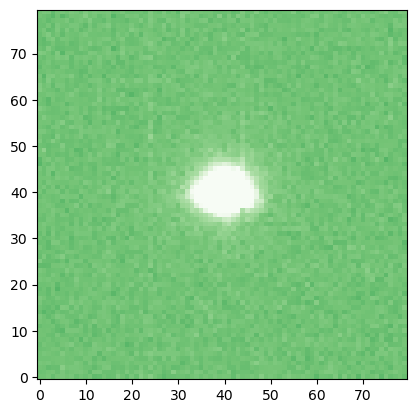

In [3]:
#and focus on the star we want to get the SNR of:
xref = 752
yref = 1291

extra_sky_pxl = 40

photom_snr = cleanimg[yref-extra_sky_pxl:yref+extra_sky_pxl, 
                      xref-extra_sky_pxl:xref+extra_sky_pxl]


qm = np.median( photom_snr)
qs = np.std( photom_snr )

dm = plt.imshow( photom_snr, vmin=qm-0.5*qs, vmax=qm+0.5*qs,  cmap='Greens_r' , origin='lower')


In [ ]:
#let's get astropy's apertures:
#from photutils.aperture import CircularAperture
#from photutils.aperture import SkyCircularAperture

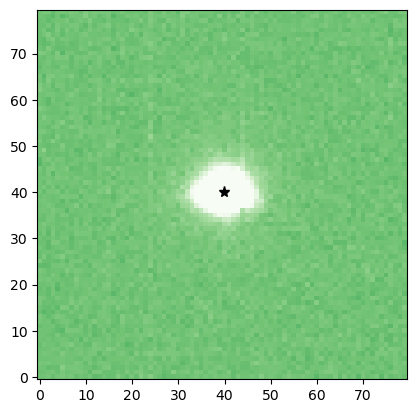

In [4]:
#get the center of the centroid first:
xcen1, ycen1 = centroid_com( photom_snr ) 

#and visualize it:
plt.imshow( photom_snr, vmin=qm-0.5*qs, vmax=qm+0.5*qs,  cmap='Greens_r' , origin='lower')
dm = plt.plot( xcen1, ycen1, marker = '*', color = 'black', markersize = 8)

In [5]:
#first hard fit of the Gaussian as before to test vs centroid center:
seewidth = 2
guess = ((seewidth, seewidth), (ycen1, xcen1), photom_snr.max())
(fw, fc, fh, fe) = g.fitgaussian(photom_snr - np.median( photom_snr ), guess=guess)
print("  wy          wx            cy           cx           height")
print(fw, fc, fh)
print(fe)

#compare with:
print( 'ycen/xcen', ycen1, xcen1 )



  wy          wx            cy           cx           height
[1.36277073 1.78575997] [40.14843685 40.1262525 ] 11967.455770897463
[5.82420042e-05 7.63205524e-05 5.82422455e-05 7.63205529e-05
 5.11464048e-01]
ycen/xcen 39.98278717444643 39.94327626847322


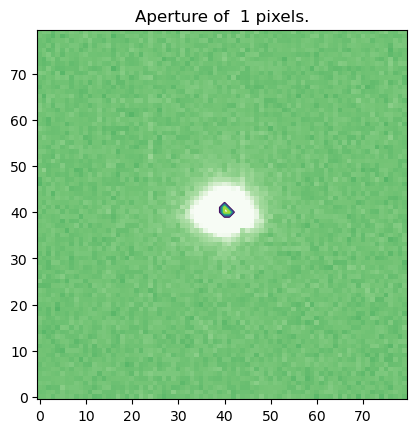

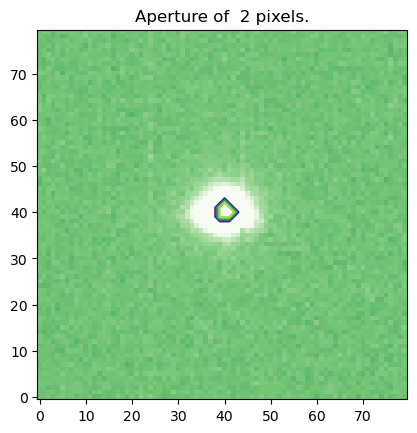

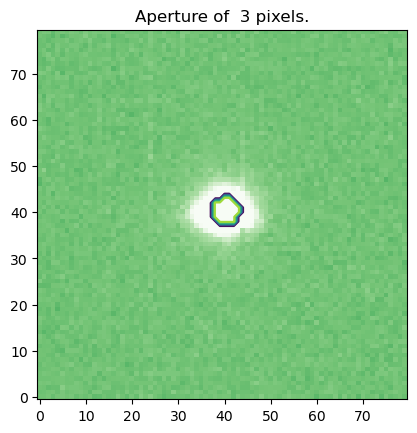

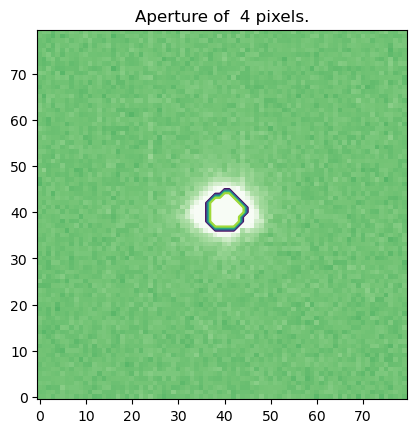

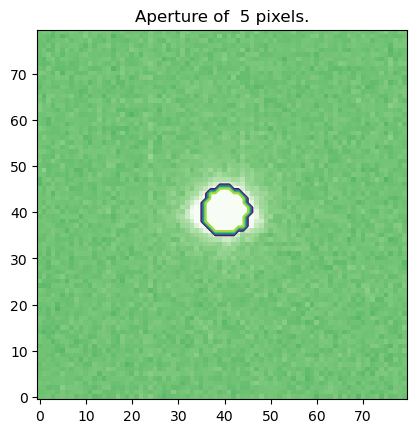

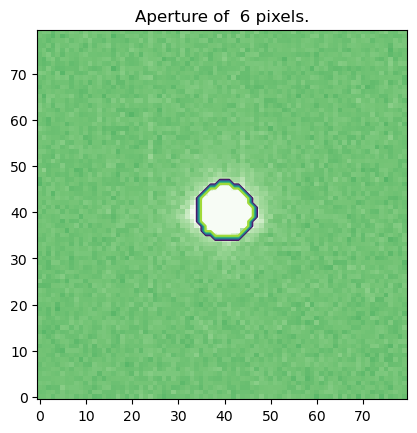

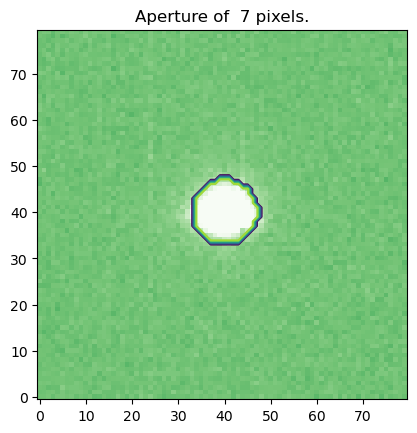

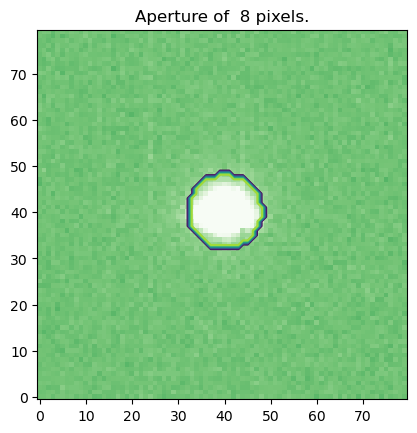

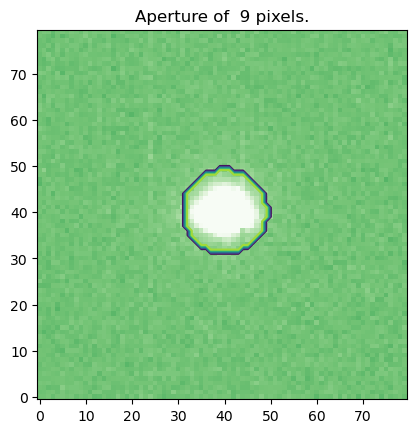

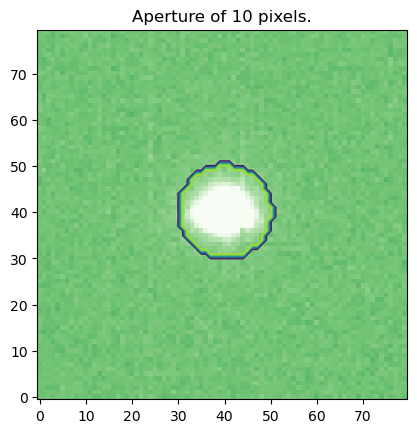

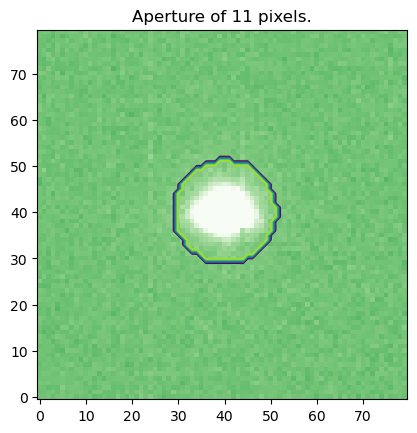

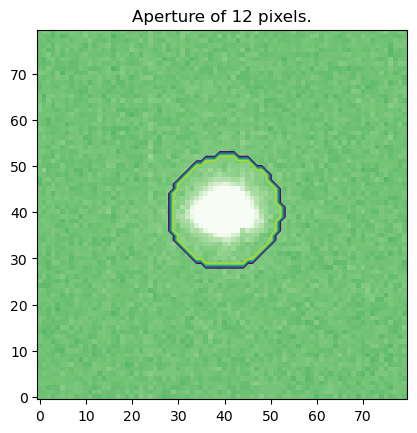

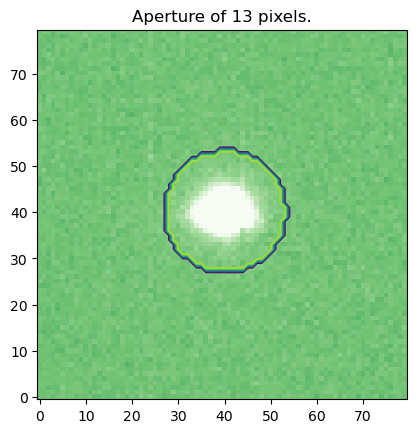

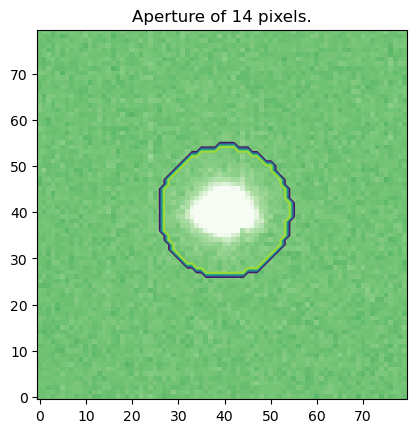

In [6]:
swid = np.arange( 1, 16, 1)

tot_cnt = np.zeros( len(swid) )

for w in range( len(swid)-1 ):
    
    aper = d.disk( swid[ w ],  fc, photom_snr.shape ) 
    
    plt.imshow( photom_snr, vmin=qm-0.5*qs, vmax=qm+0.5*qs,  cmap='Greens_r' , origin='lower')
    plt.contour(aper )
    plt.title('Aperture of {0:2d} pixels.'.format(swid[ w ]))
    plt.show()
    
    #sum the intensity in your disk:
    tot_cnt[ w ] = np.sum( photom_snr[ aper ] ) 
    

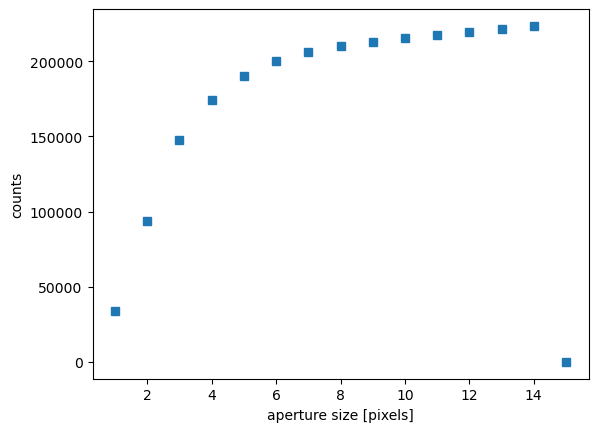

In [7]:
#now plot the counts from the different aperture trials:
plt.plot( swid, tot_cnt , marker = 's', linestyle = 'none')
plt.xlabel('aperture size [pixels]')
dm = plt.ylabel( 'counts')

/opt/anaconda3/envs/astroconda/lib/python3.7/site-packages/ipykernel_launcher.py:3: UserWarning: Attempted to set non-positive bottom ylim on a log-scaled axis.
Invalid limit will be ignored.
  This is separate from the ipykernel package so we can avoid doing imports until


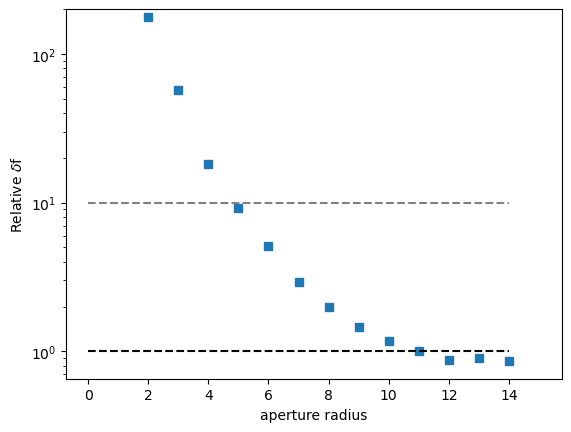

In [8]:
#and plot the relative change from each aperture to the next:
plt.semilogy( swid[ 1 : ], (np.diff(tot_cnt)/tot_cnt[ : len(swid)-1])*100,marker = 's', linestyle = 'none' )
plt.ylim( 0, 200)
plt.plot( np.arange(15), np.repeat( 10, 15 ) ,linestyle = '--', 
        color = 'gray') #line of 10% change in flux 
plt.plot( np.arange(15), np.repeat( 1, 15 ) ,linestyle = '--', 
        color = 'black') #line of 1% change in flux 
plt.ylabel('Relative $\delta$f')
dm = plt.xlabel('aperture radius')

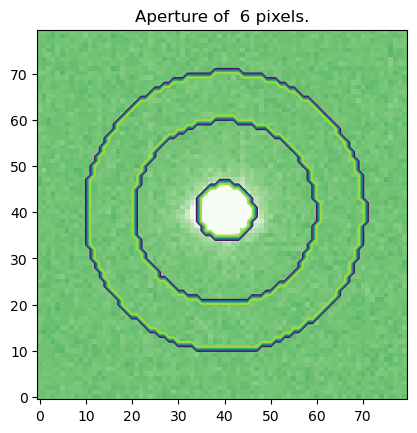

In [9]:
#let's get a sky disk aperture

skyin  = 20.
skyout = 30.

skymask =   d.disk(skyout, fc, photom_snr.shape) \
          ^ d.disk(skyin,  fc, photom_snr.shape)

plt.imshow( photom_snr, vmin=qm-0.5*qs, vmax=qm+0.5*qs,  cmap='Greens_r' , origin='lower')
aper = d.disk( 6,  fc, photom_snr.shape ) 
plt.contour( aper )

plt.contour( skymask )
plt.title('Aperture of {0:2d} pixels.'.format(6))
plt.show()

In [10]:
#get total counts of aperture and sky aperture:
Nap   = np.sum( aper )
Nsky  = np.sum( skymask )

#get total counts in sky:
sky_sum = np.sum( photom_snr[ skymask ] )

In [11]:
print( 'star counts:',tot_cnt[5], 'raw background per pixel:', sky_sum / Nsky)

star counts: 200116.8125 raw background per pixel: 13.443177977894402


In [12]:
#we still need to have our dark...let's assume the median dark is:

biasdata = np.reshape( np.random.normal(loc=1.0, scale=1.0, 
                                        size=len(photom_snr)**2) , photom_snr.shape )


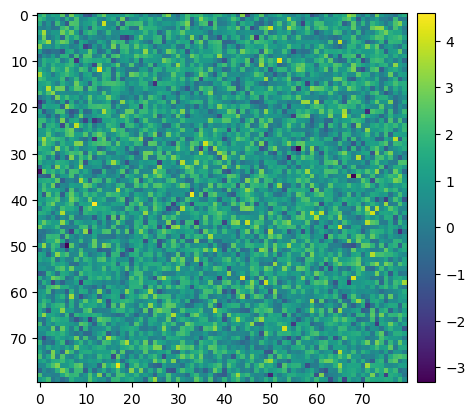

In [13]:
im1 = plt.imshow( biasdata )
plt.colorbar( im1,fraction=0.045, pad=0.02 )
plt.show()

In [14]:
#get the dark counts:
sky_sum_dark  = np.sum( biasdata[ skymask ] )
aper_sum_dark = np.sum( photom_snr[ skymask ] )
print( 'star area dark counts:', aper_sum_dark, 'background area dark counts:', sky_sum_dark )

star area dark counts: 21132.676 background area dark counts: 1493.7467886264685


In [15]:
#assume a 10 bias counts:
print(  'background per pixel:', (sky_sum - sky_sum_dark) / Nsky ,
        'dark current per pixel:', (sky_sum_dark - 10) / Nsky )

background per pixel: 12.492957374442451 dark current per pixel: 0.9438592802967357


In [16]:
#assume total readout noise of 2 electrons

In [17]:
#now let's go back to the FITS file info to see the GAIN:
hdu = fits.open('examplecleanimage2.fits')
hdu[0].header

SIMPLE  =                    T / Written by IDL:  Sun Jan  5 19:29:06 2020      
BITPIX  =                  -32 / IEEE single precision floating point           
NAXIS   =                    2  / NUMBER OF AXES                                
NAXIS1  =                 2100  / NUMBER OF COLUMNS                             
NAXIS2  =                 2068  / NUMBER OF ROWS                                
BSCALE  =        1.0000000E+00  / PHYSICAL = BSCALE * DATA + BZERO              
BZERO   =                    0 /                                                
DATE    = '2005-06-29'          / UT Date of file creation (CCYY-MM-DD)         
ORIGIN  = 'Institute for Astronomy'  / University of Hawaii                     
LATITUDE=              19.8261  / Latitude (degrees N)                          
LONGITUD=            -155.4708  / Longitude (degrees E)                         
TELESCOP= '2.2m UH '            / Telescope used for observation                
FRATIO  =                 10

In [18]:
GAIN  =  1.740  # Nominal gain (e-/ADU)

In [19]:
# let's calculate the e- per category:
n_read = 2 
n_sky  =  (sky_sum - sky_sum_dark) / Nsky  * GAIN
n_dark =  (sky_sum_dark - 10) / Nsky * GAIN
n_star =  tot_cnt[5] - (Nap/Nsky)*sky_sum *GAIN 



In [20]:
#get SNR:
snr = n_star/ np.sqrt( n_sky + n_dark + n_read + n_star ) 

In [21]:
print('SNR of {0:3.0f}'.format(snr) )

#compare with:
print('SNR assuming noise dominated {0:3.0f}'.format( np.sqrt(n_star) ))

# you can see it in the image too ;) 

SNR of 444
SNR assuming noise dominated 444


### Let's try now a fainter source that is background limited:

### ICA (50 min) 

### Get file galimage.fits. This is a cutout of a science-quality image that is centered on a galaxy. Note that this galaxy is not a point-source. It is instead what's called an "extended source". 
- plot the image to see what we are dealing with

    

- Find the centroid of the galaxy that lies in the middle of your image
     - Note that the galaxy of interest is located at x = 200.3, y = 200.2; 
        - also, note that there is a star near the galaxy 50-60 pixels away, that will show up in the radial profile you make later on

- use a code like what we used before to plot a radial profile of the galaxy. 


- estimate the sky's contribution to the pixels. Find the median value of the image within each of 10 rings, each 5 pixels thick. 
| Ring  | $r_\mathrm{in}$ | $r_\mathrm{out}$ |
|:-------------: |:-------------: |:-------------: |
|   1 |   15 | 20 |
|   2 |   20 | 25 |
|   3 |   25 | 30 |
| ... | ... | ... |

        - make a plot that shows these median values on top of the radial profile.
        - plot the image with rings 1 and then 2 overplotted. Notice that the first and second rings clearly contain some galaxy flux  and so could not be used as a true estimate of the sky! 
            - Also note that the sky estimate is only slightly elevated in the rings that contain the star. The median is a good way to minimize the influence of interfering sources like this. (Though to be extra careful it can be a good idea to avoid using those rings anyway.)
        - What would your estimate for the sky value be?
    


- Let's take the sky value to be the median of some of the better values you found: 592.81. Make a plot that shows the net counts of the galaxy as a function of aperture radius. Try aperture radii between 2 pixels and including 30 pixels in steps of 1 pixel. Note that for this you could ignore the pixelization problem, although in the real world you shouldn't. Recall that the net counts $c_n$ is $c_n = c_g - n_\mathrm{pix}c_s$ where $c_g$ is the gross counts, $c_s$ is the sky contribution per pixel (592.81), and $n_\mathrm{pix}$ is the number of pixels in the aperture.



- Use the CCD Equation to make a plot of the SNR as a function of aperture radius. Note that the detector used to take the image has a gain $G=1.74 e^-$/count and a read noise NR of 6.0 $e^-$. Assume that the dark current contribution is negligible. Remember that the CCD Equation involves $e^-$, not counts. The number of $e^-$ is simply the counts times the gain.

- note that the plot shows that if you want to maximize the SNR from the measurement, you should use an aperture radius of about 7 pixels. However if you are interested in finding the magnitude of the entire galaxy, would that be big enough? No it wouldn't, since the galaxy clearly extends more than 7 pixels away from its centroid. This is the fundamental problem of photometry of extended sources; bigger apertures are needed to include the whole object but the SNR does suffer.